In [68]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
def calc_com_mat(trial_mat, max_trial=5):
    shifts = np.arange(-28,29)
    corr_mat = np.zeros((max_trial,max_trial, shifts.shape[0]))
    com_mat = np.nan*np.zeros([max_trial,max_trial])
    
    for t1, t2 in itertools.permutations(range(max_trial),2):
        # print(t1,t2)
        for k, shift in enumerate(shifts):

            if shift <0:
                mat2 = trial_mat[t2,-shift:,:]
                mat1 = trial_mat[t1,:mat2.shape[0],:]
            else:
                mat1 = trial_mat[t1,shift:,:]
                mat2 = trial_mat[t2,:mat1.shape[0],:]

            assert mat1.shape==mat2.shape

            r,_ = sp.stats.pearsonr(mat1,mat2,axis=-1)
           
            corr_mat[t1,t2,k] = np.nanmean(r)
        com_mat[t1,t2] = (shifts*corr_mat[t1,t2,:]).sum()/corr_mat[t1,t2,:].sum()
        # com_mat[t1,t2] = shifts[np.argmax(corr_mat[t1,t2,:])]
        
    return com_mat



In [ ]:
com_mat_dict = {}
day = 0
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    com_mat_dict[cond] = []
    for mouse in mice:
        print(mouse)
        sess = u.load_single_day(mouse, day)
        trial_mask = sess.trial_info['LR']==sess.novel_arm


        trial_mat = sess.trial_matrices['F_dff_norm'][trial_mask,:,:]
        trial_mat[np.isnan(trial_mat)]=0

        com_mat_dict[cond].append(calc_com_mat(trial_mat,max_trial=5))
            

4467331.1
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


/tmp/ipykernel_44428/3146375576.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(mat1,mat2,axis=-1)


4467331.2
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}


/tmp/ipykernel_44428/3146375576.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(mat1,mat2,axis=-1)


4467332.1
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
4467332.2
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}


...

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


4467975.4
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
4467975.5
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
Cre7
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


/tmp/ipykernel_44428/3146375576.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(mat1,mat2,axis=-1)


Cre9
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 0}


/tmp/ipykernel_44428/3146375576.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(mat1,mat2,axis=-1)


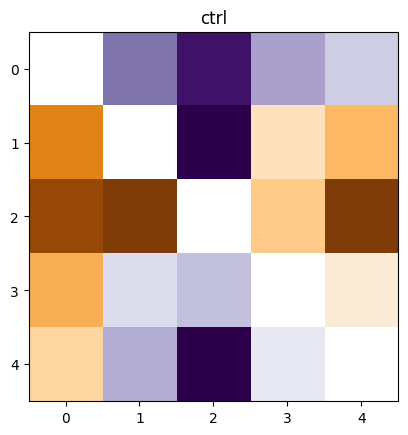

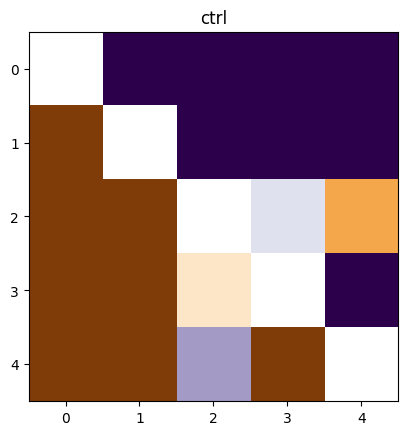

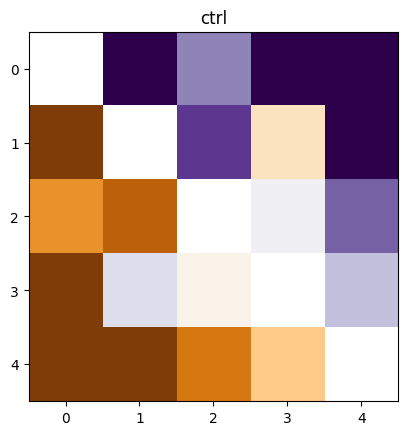

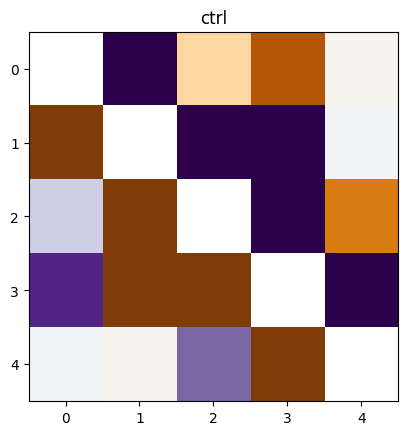

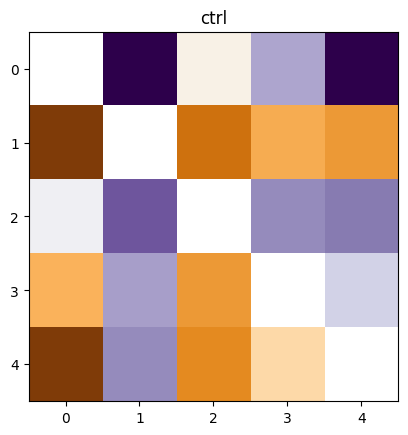

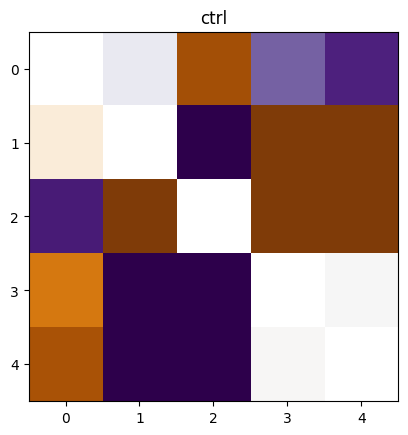

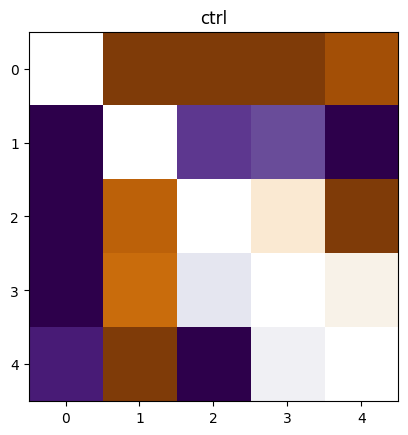

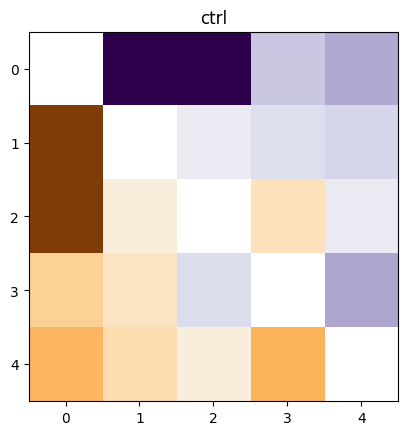

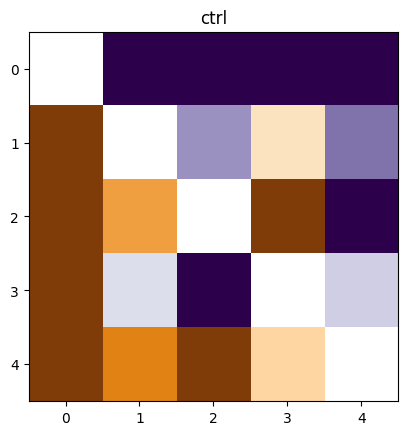

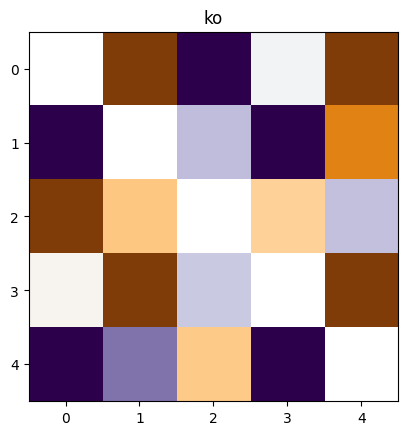

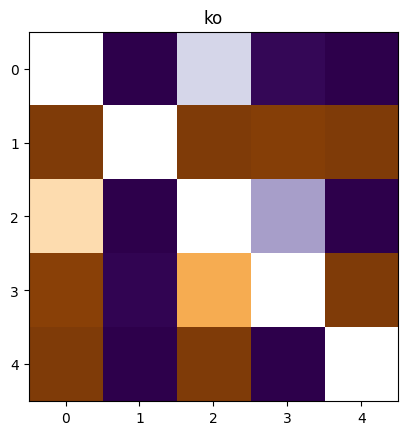

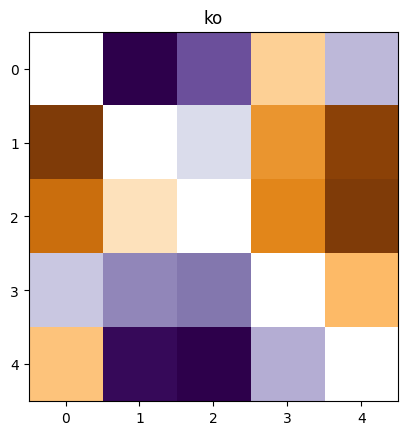

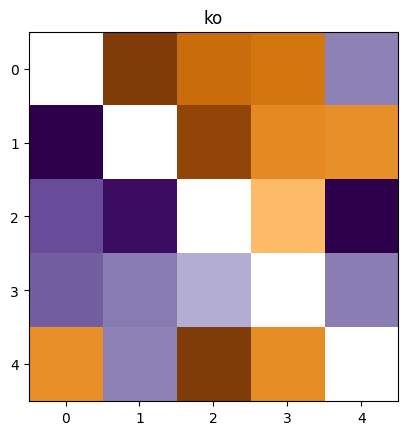

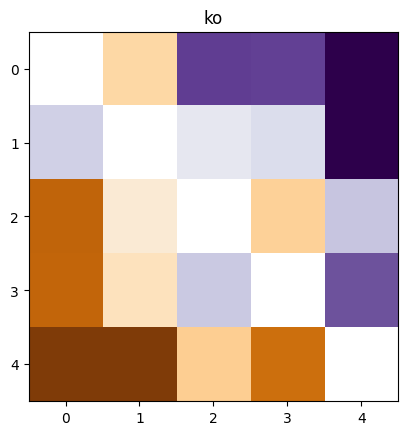

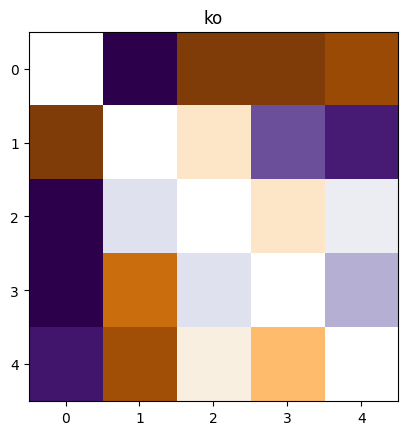

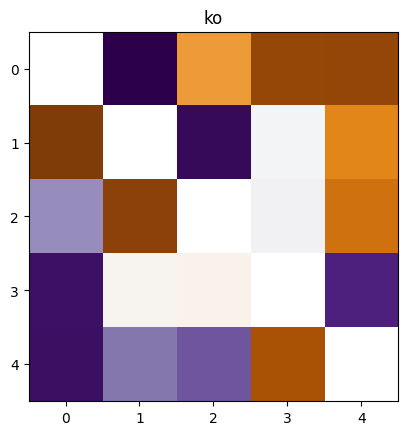

In [77]:
for k, mats in com_mat_dict.items():

    for mat in mats:
        fig, ax = plt.subplots()
        ax.imshow(mat, cmap='PuOr', vmin=-5, vmax=5)
        ax.set_title(k)

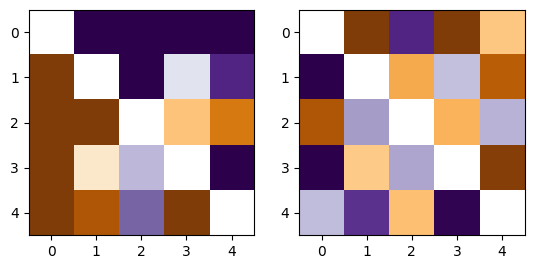

In [78]:
fig, ax= plt.subplots(1,2)
ax[0].imshow(np.array(com_mat_dict['ctrl']).mean(axis=0), 
             cmap='PuOr', vmin=-2, vmax=2)
ax[1].imshow(np.array(com_mat_dict['ko']).mean(axis=0),
             cmap='PuOr', vmin=-2, vmax=2)

WilcoxonResult(statistic=np.float64(12.0), pvalue=np.float64(0.25))
WilcoxonResult(statistic=np.float64(13.0), pvalue=np.float64(0.9375))
RanksumsResult(statistic=np.float64(-1.1114378604524227), pvalue=np.float64(0.2663799233424825))


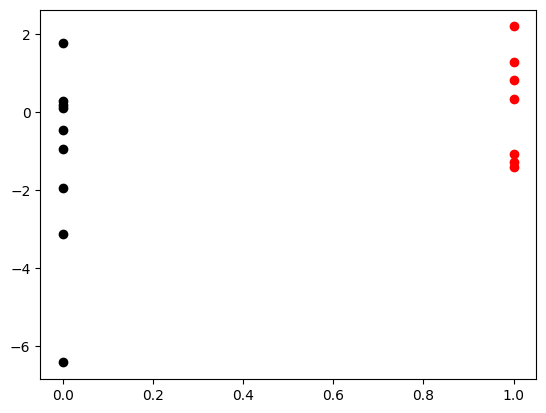

In [80]:
fig, ax = plt.subplots()
ctrl_mu = []
for mat in com_mat_dict['ctrl']:
    ctrl_mu.append(np.nanmean(mat[np.tril_indices_from(mat,k=1)]))
ax.scatter(np.zeros_like(ctrl_mu), ctrl_mu, color='black')

ko_mu = []
for mat in com_mat_dict['ko']:
    ko_mu.append(np.nanmean(mat[np.tril_indices_from(mat,k=1)]))
ax.scatter(np.ones_like(ko_mu), ko_mu, color='red')

print(sp.stats.wilcoxon(ctrl_mu))
print(sp.stats.wilcoxon(ko_mu))
print(sp.stats.ranksums(ctrl_mu, ko_mu))

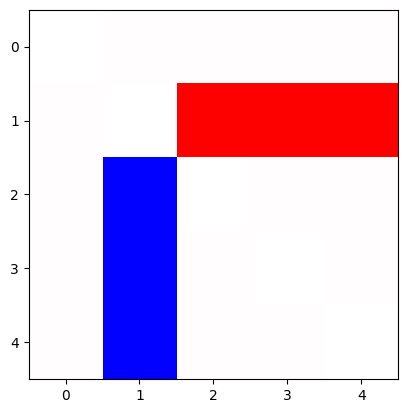

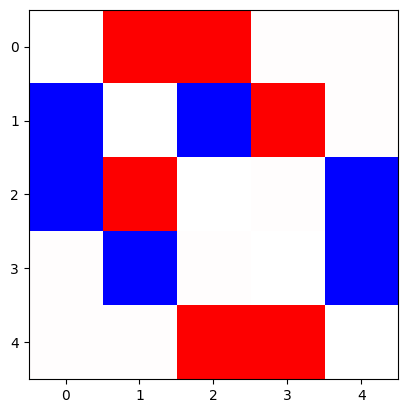

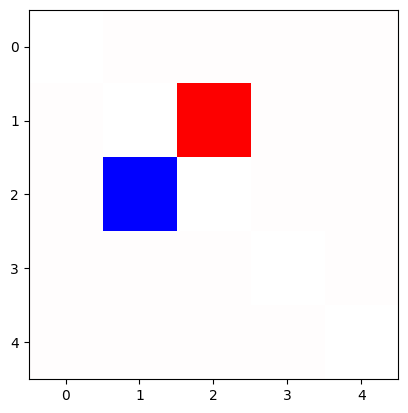

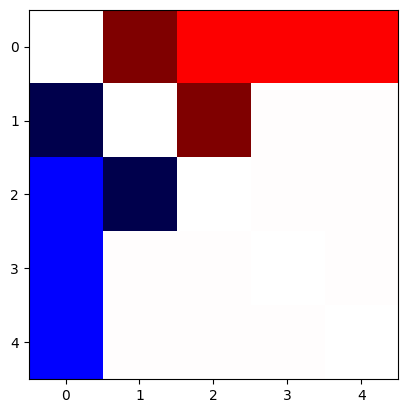

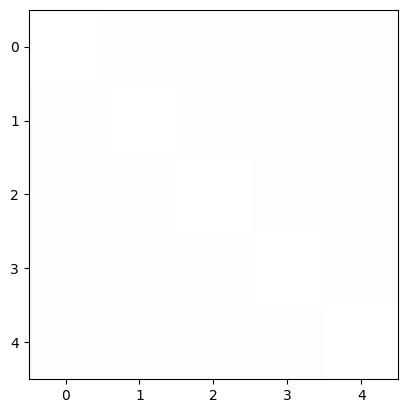

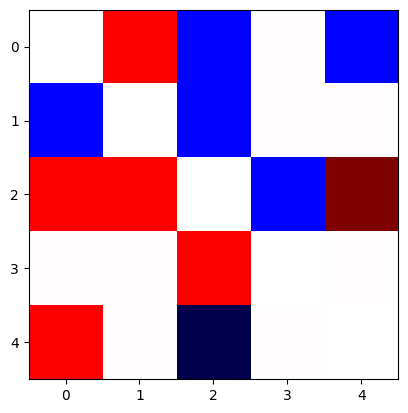

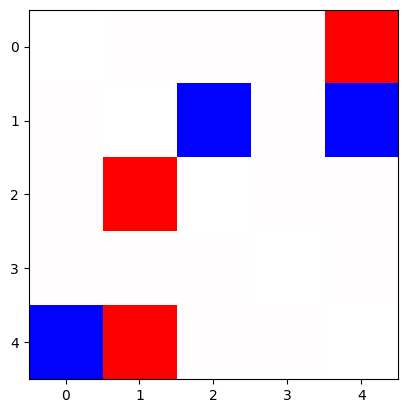

In [88]:
chan0 = np.array(com_mat_dict['channel_0'])
chan1 = np.array(com_mat_dict['channel_1'])

for r in range(chan0.shape[0]):
    fig, ax = plt.subplots()
    ax.imshow(chan1[r,:,:]-chan0[r,:,:], vmin=-2, vmax=2, cmap='seismic')

In [8]:
chan0 = []
for mat in com_mat_dict['channel_0']:
    chan0.append(mat[np.tril_indices_from(mat,k=-1)].mean())

chan1 = []
for mat in com_mat_dict['channel_1']:
    chan1.append(mat[np.tril_indices_from(mat,k=-1)].mean())

KeyError: 'channel_0'

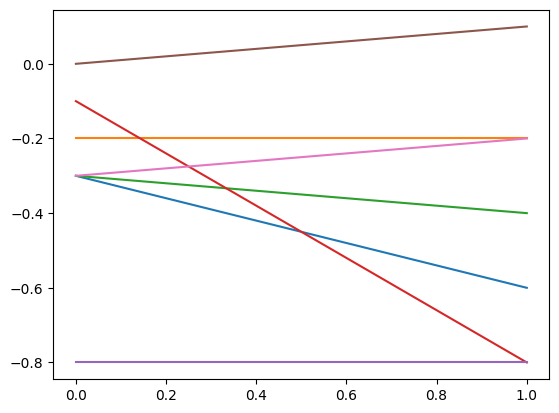

In [ ]:
fig, ax = plt.subplots()
ax.plot([0,1], np.vstack((chan0,chan1)))

In [91]:
sp.stats.wilcoxon(chan0,chan1)

WilcoxonResult(statistic=np.float64(3.0), pvalue=np.float64(0.3125))